In [ ]:
# =============================================================================
# ETAPA 1: ANÁLISE EXPLORATÓRIA E DETECÇÃO DE VIÉS NO COMPAS
# =============================================================================
# Objetivo: Carregar, limpar e analisar o dataset COMPAS com foco na detecção
# de viés racial, estabelecendo as bases para as modelagens posteriores.
# =============================================================================

print("🚀 INICIANDO ETAPA 1 - ANÁLISE EXPLORATÓRIA DO COMPAS")
print("=" * 70)

# 1.1 CONFIGURAÇÃO DO AMBIENTE E IMPORTAÇÕES
# =============================================================================
# Importação de bibliotecas necessárias para análise de dados, visualização
# e estatísticas. Configurações iniciais para garantir reprodutibilidade.
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Configurações de visualização para melhor clareza dos gráficos
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

print("✅ BIBLIOTECAS IMPORTADAS COM SUCESSO")
print("   • Pandas/Numpy: Análise de dados")
print("   • Matplotlib/Seaborn: Visualizações")
print("   • Configurações aplicadas para gráficos claros e consistentes")

🚀 INICIANDO ETAPA 1 - ANÁLISE EXPLORATÓRIA DO COMPAS
✅ BIBLIOTECAS IMPORTADAS COM SUCESSO
   • Pandas/Numpy: Análise de dados
   • Matplotlib/Seaborn: Visualizações
   • Configurações aplicadas para gráficos claros e consistentes


In [ ]:
# 1.2 CARREGAMENTO E INSPEÇÃO INICIAL DOS DADOS
# =============================================================================
# Carregamento do dataset original COMPAS da ProPublica
# Inspeção inicial para entender estrutura, dimensões e qualidade dos dados
# =============================================================================

from google.colab import files
import io

print("📁 CARREGAMENTO DO DATASET COMPAS")
print("   • Fonte: ProPublica - compas-scores-two-years.csv")
print("   • Período: Dois anos de acompanhamento")
print("   • Foco: Scores de risco e reincidência real")

# Upload do arquivo
uploaded = files.upload()

# Carregar os dados
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

print(f"✅ DATASET CARREGADO: {df.shape[0]} linhas × {df.shape[1]} colunas")

# Inspeção detalhada da estrutura do dataset
print("\n🔍 INSPEÇÃO INICIAL DO DATASET")

print("\n📋 PRIMEIRAS LINHAS (amostra da estrutura):")
display(df.head(3))

print("\n🏷️  COLUNAS PRINCIPAIS E TIPOS DE DADOS:")
print(df.info())

print("\n📊 ESTATÍSTICAS DESCRITIVAS (variáveis numéricas):")
display(df.describe())

print("\n🎯 VARIÁVEIS CATEGÓRICAS RELEVANTES:")
categorical_cols = ['race', 'sex', 'age_cat', 'c_charge_degree', 'score_text']
for col in categorical_cols:
    if col in df.columns:
        print(f"   • {col}: {df[col].unique()}")

📁 CARREGAMENTO DO DATASET COMPAS
   • Fonte: ProPublica - compas-scores-two-years.csv
   • Período: Dois anos de acompanhamento
   • Foco: Scores de risco e reincidência real


Saving compas-scores-two-years.csv to compas-scores-two-years.csv
✅ DATASET CARREGADO: 7214 linhas × 53 colunas

🔍 INSPEÇÃO INICIAL DO DATASET

📋 PRIMEIRAS LINHAS (amostra da estrutura):


,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1



🏷️  COLUNAS PRINCIPAIS E TIPOS DE DADOS:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7214 entries, 0 to 7213
Data columns (total 53 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       7214 non-null   int64  
 1   name                     7214 non-null   object 
 2   first                    7214 non-null   object 
 3   last                     7214 non-null   object 
 4   compas_screening_date    7214 non-null   object 
 5   sex                      7214 non-null   object 
 6   dob                      7214 non-null   object 
 7   age                      7214 non-null   int64  
 8   age_cat                  7214 non-null   object 
 9   race                     7214 non-null   object 
 10  juv_fel_count            7214 non-null   int64  
 11  decile_score             7214 non-null   int64  
 12  juv_misd_count           7214 non-null   int64  
 13  juv_other_count          7214 non-nu

,id,age,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_days_from_compas,is_recid,r_days_from_arrest,violent_recid,is_violent_recid,decile_score.1,v_decile_score,priors_count.1,start,end,event,two_year_recid
count,7214.000000,7214.000000,7214.000000,7214.000000,7214.000000,7214.000000,7214.000000,6907.000000,7192.000000,7214.000000,2316.000000,0.0,7214.000000,7214.000000,7214.000000,7214.000000,7214.000000,7214.000000,7214.000000,7214.000000
mean,5501.255753,34.817993,0.067230,4.509565,0.090934,0.109371,3.472415,3.304763,57.731368,0.481148,20.269430,NaN,0.113529,4.509565,3.691849,3.472415,11.465068,553.436651,0.382867,0.450652
std,3175.706870,11.888922,0.473972,2.856396,0.485239,0.501586,4.882538,75.809505,329.740215,0.499679,74.871668,NaN,0.317261,2.856396,2.510148,4.882538,46.954563,399.020583,0.486120,0.497593
min,1.000000,18.000000,0.000000,1.000000,0.000000,0.000000,0.000000,-414.000000,0.000000,0.000000,-1.000000,NaN,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2735.250000,25.000000,0.000000,2.000000,0.000000,0.000000,0.000000,-1.000000,1.000000,0.000000,0.000000,NaN,0.000000,2.000000,1.000000,0.000000,0.000000,148.250000,0.000000,0.000000
50%,5509.500000,31.000000,0.000000,4.000000,0.000000,0.000000,2.000000,-1.000000,1.000000,0.000000,0.000000,NaN,0.000000,4.000000,3.000000,2.000000,0.000000,530.500000,0.000000,0.000000
75%,8246.500000,42.000000,0.000000,7.000000,0.000000,0.000000,5.000000,0.000000,2.000000,1.000000,1.000000,NaN,0.000000,7.000000,5.000000,5.000000,1.000000,914.000000,1.000000,1.000000
max,11001.000000,96.000000,20.000000,10.000000,13.000000,17.000000,38.000000,1057.000000,9485.000000,1.000000,993.000000,NaN,1.000000,10.000000,10.000000,38.000000,937.000000,1186.000000,1.000000,1.000000



🎯 VARIÁVEIS CATEGÓRICAS RELEVANTES:
   • race: ['Other' 'African-American' 'Caucasian' 'Hispanic' 'Native American'
 'Asian']
   • sex: ['Male' 'Female']
   • age_cat: ['Greater than 45' '25 - 45' 'Less than 25']
   • c_charge_degree: ['F' 'M']
   • score_text: ['Low' 'High' 'Medium']


In [ ]:
# 1.3 PRÉ-PROCESSAMENTO E FILTROS
# =============================================================================
# Aplicação dos filtros da ProPublica para garantir comparabilidade com
# estudos anteriores e remoção de dados inconsistentes ou incompletos
# =============================================================================

print("🎯 APLICAÇÃO DOS FILTROS PROPUBLICA")
print("   • Critérios originais do estudo de referência")
print("   • Garantia de comparabilidade metodológica")

# Fazer uma cópia do dataframe original para preservar dados brutos
df_raw = df.copy()

# Aplicar os filtros recomendados pela ProPublica
df_filtered = df_raw[
    (df_raw['days_b_screening_arrest'] <= 30) &
    (df_raw['days_b_screening_arrest'] >= -30) &
    (df_raw['is_recid'] != -1) &
    (df_raw['c_charge_degree'].isin(['F', 'M'])) &
    (df_raw['score_text'] != 'N/A')
].copy()

print(f"📈 REDUÇÃO DO DATASET APÓS FILTROS:")
print(f"   • Original: {len(df_raw)} casos")
print(f"   • Filtrado: {len(df_filtered)} casos")
print(f"   • Redução: {len(df_raw) - len(df_filtered)} casos ({(1-len(df_filtered)/len(df_raw))*100:.1f}%)")

🎯 APLICAÇÃO DOS FILTROS PROPUBLICA
   • Critérios originais do estudo de referência
   • Garantia de comparabilidade metodológica
📈 REDUÇÃO DO DATASET APÓS FILTROS:
   • Original: 7214 casos
   • Filtrado: 6172 casos
   • Redução: 1042 casos (14.4%)


In [ ]:
# 1.4 DECISÃO ESTRATÉGICA: FOCO NAS RAÇAS PRINCIPAIS
# =============================================================================
# Análise da distribuição racial e decisão metodológica de focar nas duas
# raças predominantes para garantir robustez estatística e clareza analítica
# =============================================================================

print("🎯 ANÁLISE DA DISTRIBUIÇÃO RACIAL")
print("   • Avaliação de representatividade estatística")

distribuicao_racial = df_filtered['race'].value_counts(normalize=True)
print("\n📊 DISTRIBUIÇÃO RACIAL COMPLETA (%):")
for race, prop in distribuicao_racial.items():
    print(f"   • {race}: {prop:.3f} ({distribuicao_racial[race]*100:.1f}%)")

# DECISÃO METODOLÓGICA: Focar nas duas raças principais
races_principais = ['African-American', 'Caucasian']
df_principal = df_filtered[df_filtered['race'].isin(races_principais)].copy()

print(f"\n🔍 JUSTIFICATIVA PARA FOCO ANALÍTICO:")
print(f"   • African-American + Caucasian = {(distribuicao_racial['African-American'] + distribuicao_racial['Caucasian'])*100:.1f}% da amostra")
print(f"   • Hispanic: apenas {distribuicao_racial['Hispanic']*100:.1f}% (6x menor que African-American)")
print(f"   • Outras raças: < 6% combinadas (amostras muito pequenas para análise robusta)")

print(f"\n✅ DECISÃO: Foco em African-American vs Caucasian")
print(f"   • Amostra final: {len(df_principal)} casos")
print(f"   • Distribuição: {df_principal['race'].value_counts(normalize=True).round(3).to_dict()}")

🎯 ANÁLISE DA DISTRIBUIÇÃO RACIAL
   • Avaliação de representatividade estatística

📊 DISTRIBUIÇÃO RACIAL COMPLETA (%):
   • African-American: 0.514 (51.4%)
   • Caucasian: 0.341 (34.1%)
   • Hispanic: 0.082 (8.2%)
   • Other: 0.056 (5.6%)
   • Asian: 0.005 (0.5%)
   • Native American: 0.002 (0.2%)

🔍 JUSTIFICATIVA PARA FOCO ANALÍTICO:
   • African-American + Caucasian = 85.5% da amostra
   • Hispanic: apenas 8.2% (6x menor que African-American)
   • Outras raças: < 6% combinadas (amostras muito pequenas para análise robusta)

✅ DECISÃO: Foco em African-American vs Caucasian
   • Amostra final: 5278 casos
   • Distribuição: {'African-American': 0.602, 'Caucasian': 0.398}


📊 ANÁLISE EXPLORATÓRIA DAS VARIÁVEIS PRINCIPAIS
   • Caracterização da população do estudo
   • Identificação de padrões demográficos


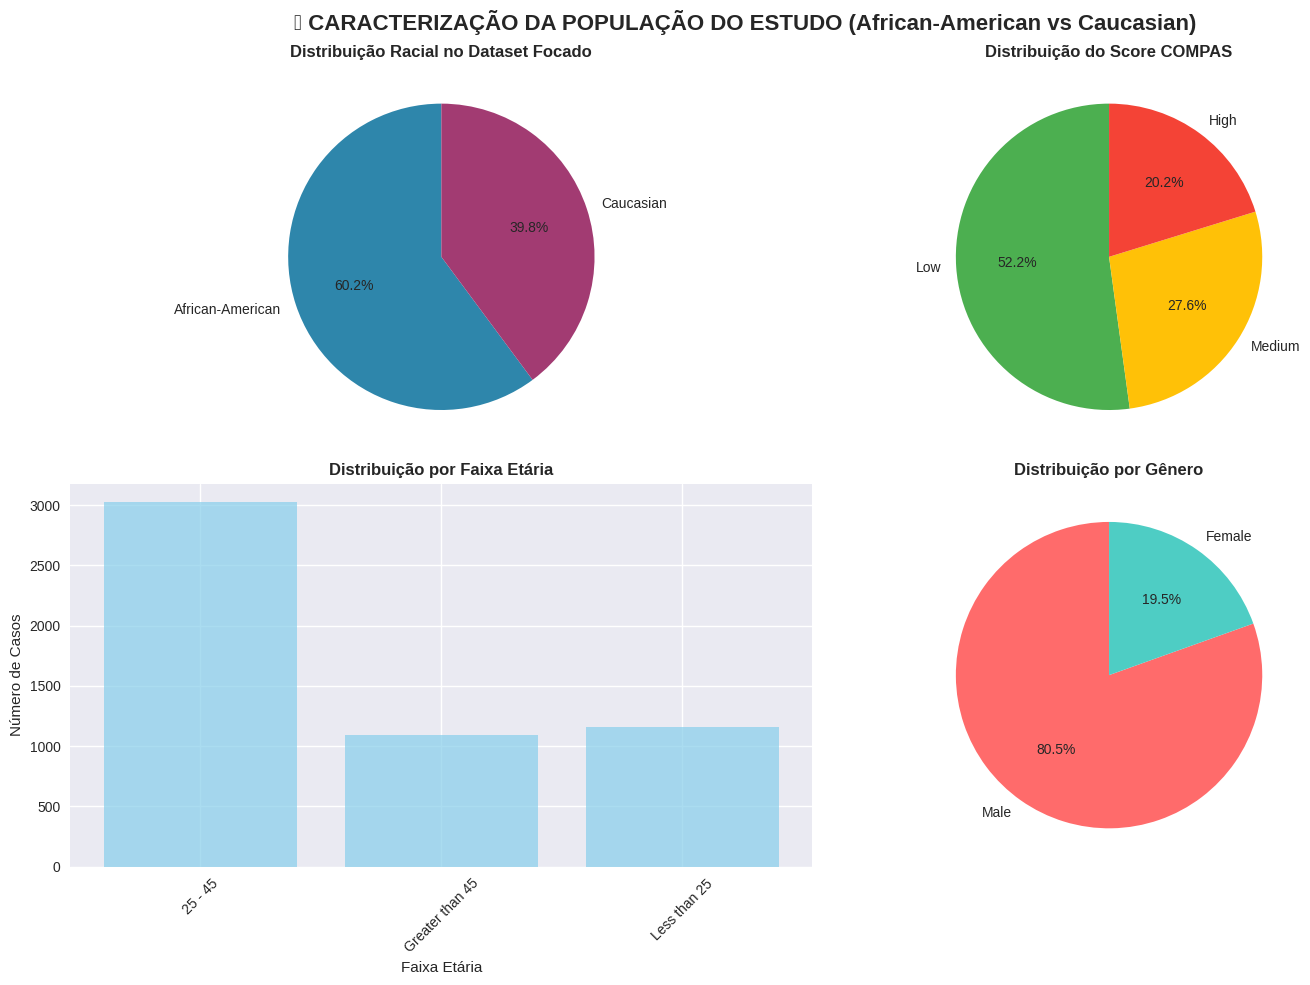

✅ CARACTERIZAÇÃO DA POPULAÇÃO CONCLUÍDA
   • Total de casos analisados: 5278
   • Scores: {'Low': np.int64(2753), 'Medium': np.int64(1457), 'High': np.int64(1068)}
   • Faixas etárias: {'25 - 45': np.int64(3026), 'Greater than 45': np.int64(1096), 'Less than 25': np.int64(1156)}


In [ ]:
# 1.5 ANÁLISE EXPLORATÓRIA DAS VARIÁVEIS PRINCIPAIS
# =============================================================================
# Visualização das distribuições das variáveis demográficas e de scores
# para entender a população do estudo e identificar padrões iniciais
# =============================================================================

print("📊 ANÁLISE EXPLORATÓRIA DAS VARIÁVEIS PRINCIPAIS")
print("   • Caracterização da população do estudo")
print("   • Identificação de padrões demográficos")

# Configuração dos gráficos
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('📋 CARACTERIZAÇÃO DA POPULAÇÃO DO ESTUDO (African-American vs Caucasian)',
             fontsize=16, fontweight='bold', y=0.98)

# Distribuição racial no dataset focado
race_dist_focused = df_principal['race'].value_counts()
axes[0,0].pie(race_dist_focused.values, labels=race_dist_focused.index,
              autopct='%1.1f%%', startangle=90, colors=['#2E86AB', '#A23B72'])
axes[0,0].set_title('Distribuição Racial no Dataset Focado', fontweight='bold')

# Distribuição do score COMPAS
score_dist = df_principal['score_text'].value_counts()
axes[0,1].pie(score_dist.values, labels=score_dist.index,
              autopct='%1.1f%%', startangle=90, colors=['#4CAF50', '#FFC107', '#F44336'])
axes[0,1].set_title('Distribuição do Score COMPAS', fontweight='bold')

# Distribuição por faixa etária
age_dist = df_principal['age_cat'].value_counts().sort_index()
axes[1,0].bar(age_dist.index, age_dist.values, color='skyblue', alpha=0.7)
axes[1,0].set_title('Distribuição por Faixa Etária', fontweight='bold')
axes[1,0].set_xlabel('Faixa Etária')
axes[1,0].set_ylabel('Número de Casos')
axes[1,0].tick_params(axis='x', rotation=45)

# Distribuição por gênero
gender_dist = df_principal['sex'].value_counts()
axes[1,1].pie(gender_dist.values, labels=gender_dist.index,
              autopct='%1.1f%%', startangle=90, colors=['#FF6B6B', '#4ECDC4'])
axes[1,1].set_title('Distribuição por Gênero', fontweight='bold')

plt.tight_layout()
plt.show()

print("✅ CARACTERIZAÇÃO DA POPULAÇÃO CONCLUÍDA")
print(f"   • Total de casos analisados: {len(df_principal)}")
print(f"   • Scores: {dict(score_dist)}")
print(f"   • Faixas etárias: {dict(age_dist)}")

⚖️ ANÁLISE INICIAL DE VIÉS RACIAL NOS SCORES COMPAS
   • Comparação da distribuição de scores entre grupos raciais
   • Identificação de disparidades iniciais

📊 DISTRIBUIÇÃO DE SCORES POR RAÇA (%):


score_text,High,Low,Medium
race,,,
African-American,26.61,42.39,30.99
Caucasian,10.60,66.90,22.49


<Figure size 1200x600 with 0 Axes>

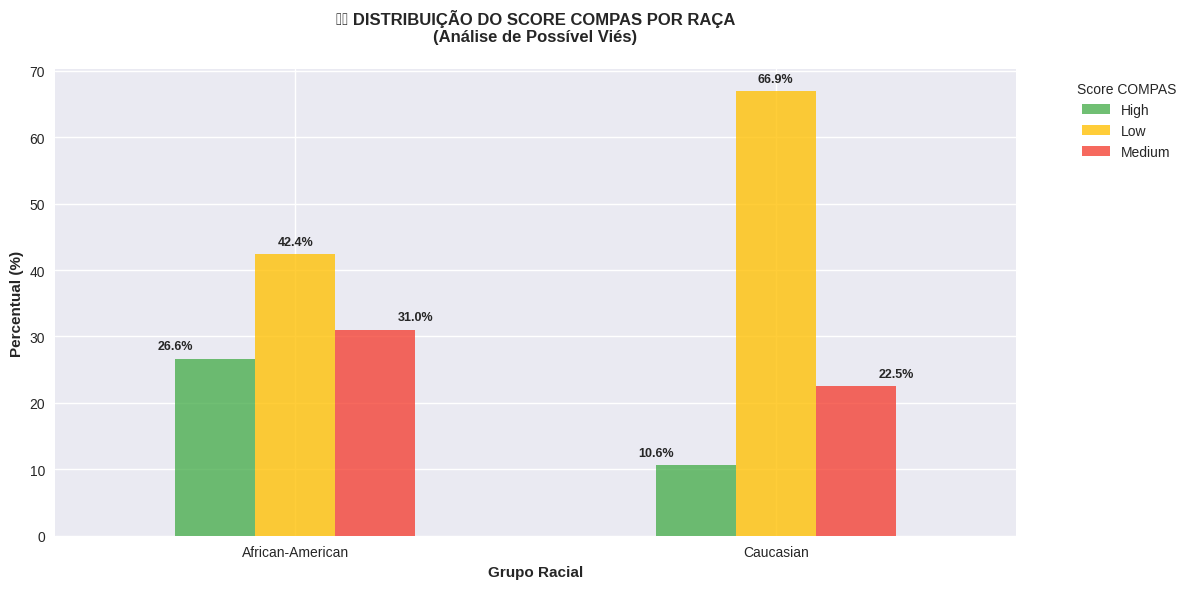


🔍 DISPARIDADES IDENTIFICADAS:
   • High Score: African-Americans têm 2.5x mais scores 'High'
   • Low Score: Caucasians têm 0.6x mais scores 'Low'


In [ ]:
# 1.6 ANÁLISE DE VIÉS - SCORE COMPAS POR RAÇA
# =============================================================================
# Investigação inicial de possíveis vieses através da distribuição
# diferenciada de scores entre grupos raciais
# =============================================================================

print("⚖️ ANÁLISE INICIAL DE VIÉS RACIAL NOS SCORES COMPAS")
print("   • Comparação da distribuição de scores entre grupos raciais")
print("   • Identificação de disparidades iniciais")

# Tabela cruzada detalhada
cross_tab = pd.crosstab(df_principal['race'], df_principal['score_text'],
                        normalize='index') * 100

print("\n📊 DISTRIBUIÇÃO DE SCORES POR RAÇA (%):")
display(cross_tab.round(2))

# Visualização comparativa
plt.figure(figsize=(12, 6))

# Gráfico de barras lado a lado
score_by_race = df_principal.groupby(['race', 'score_text']).size().unstack()
score_by_race_pct = score_by_race.div(score_by_race.sum(axis=1), axis=0) * 100

ax = score_by_race_pct.plot(kind='bar', color=['#4CAF50', '#FFC107', '#F44336'],
                           alpha=0.8, figsize=(12, 6))
plt.title('⚖️ DISTRIBUIÇÃO DO SCORE COMPAS POR RAÇA\n(Análise de Possível Viés)',
          fontweight='bold', pad=20)
plt.xlabel('Grupo Racial', fontweight='bold')
plt.ylabel('Percentual (%)', fontweight='bold')
plt.xticks(rotation=0)
plt.legend(title='Score COMPAS', bbox_to_anchor=(1.05, 1), loc='upper left')

# Adicionar valores nas barras
for i, (idx, row) in enumerate(score_by_race_pct.iterrows()):
    for j, val in enumerate(row):
        ax.text(i + j*0.25 - 0.25, val + 1, f'{val:.1f}%',
                ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

# Cálculo de disparidades
high_score_disparity = (cross_tab.loc['African-American', 'High'] /
                       cross_tab.loc['Caucasian', 'High'])
low_score_disparity = (cross_tab.loc['African-American', 'Low'] /
                      cross_tab.loc['Caucasian', 'Low'])

print(f"\n🔍 DISPARIDADES IDENTIFICADAS:")
print(f"   • High Score: African-Americans têm {high_score_disparity:.1f}x mais scores 'High'")
print(f"   • Low Score: Caucasians têm {low_score_disparity:.1f}x mais scores 'Low'")

🎯 REINCIDÊNCIA REAL vs PREDIÇÃO DO COMPAS
   • Avaliação da precisão preditiva por grupo racial
   • Identificação de possíveis vieses de classificação

📊 TAXA DE REINCIDÊNCIA REAL POR RAÇA E SCORE COMPAS:


,race,score_text,n_casos,taxa_reincidencia,desvio_padrao
0,African-American,High,845,0.7503,0.4331
1,African-American,Low,1346,0.3514,0.4776
2,African-American,Medium,984,0.5630,0.4963
3,Caucasian,High,223,0.7265,0.4468
4,Caucasian,Low,1407,0.2900,0.4539
5,Caucasian,Medium,473,0.5328,0.4995


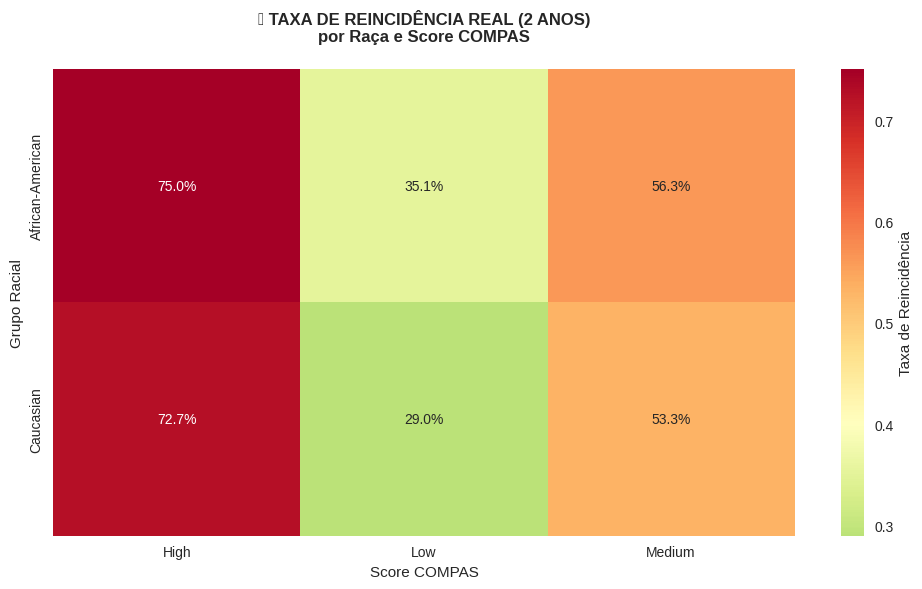


🔍 OBSERVAÇÕES SOBRE ACURÁCIA PREDITIVA:
   • African-American:
     - Score High: 75.0% de reincidência real
     - Score Low: 35.1% de reincidência real
     - Score Medium: 56.3% de reincidência real
   • Caucasian:
     - Score High: 72.7% de reincidência real
     - Score Low: 29.0% de reincidência real
     - Score Medium: 53.3% de reincidência real


In [ ]:
# 1.7 ANÁLISE DE REINCIDÊNCIA REAL vs SCORE COMPAS
# =============================================================================
# Comparação entre a predição de risco (score COMPAS) e a reincidência
# real observada em dois anos, investigando acurácia diferencial por raça
# =============================================================================

print("🎯 REINCIDÊNCIA REAL vs PREDIÇÃO DO COMPAS")
print("   • Avaliação da precisão preditiva por grupo racial")
print("   • Identificação de possíveis vieses de classificação")

# Criar análise detalhada de reincidência real por raça e score
reincidencia_analysis = df_principal.groupby(['race', 'score_text']).agg({
    'two_year_recid': ['count', 'mean', 'std']
}).round(4)

reincidencia_analysis.columns = ['n_casos', 'taxa_reincidencia', 'desvio_padrao']
reincidencia_analysis = reincidencia_analysis.reset_index()

print("\n📊 TAXA DE REINCIDÊNCIA REAL POR RAÇA E SCORE COMPAS:")
display(reincidencia_analysis)

# Visualização em heatmap
plt.figure(figsize=(10, 6))

pivot_table = reincidencia_analysis.pivot(index='race', columns='score_text',
                                         values='taxa_reincidencia')

sns.heatmap(pivot_table, annot=True, fmt='.1%', cmap='RdYlGn_r', center=0.4,
            cbar_kws={'label': 'Taxa de Reincidência'})
plt.title('🔥 TAXA DE REINCIDÊNCIA REAL (2 ANOS)\npor Raça e Score COMPAS',
          fontweight='bold', pad=20)
plt.xlabel('Score COMPAS')
plt.ylabel('Grupo Racial')
plt.tight_layout()
plt.show()

print("\n🔍 OBSERVAÇÕES SOBRE ACURÁCIA PREDITIVA:")
for race in df_principal['race'].unique():
    subset = reincidencia_analysis[reincidencia_analysis['race'] == race]
    print(f"   • {race}:")
    for _, row in subset.iterrows():
        print(f"     - Score {row['score_text']}: {row['taxa_reincidencia']:.1%} de reincidência real")

In [ ]:
# 1.8 ANÁLISE DE FALSOS POSITIVOS E FALSOS NEGATIVOS
# =============================================================================
# Cálculo das métricas fundamentais de fairness: False Positive Rate (FPR)
# e False Negative Rate (FNR) por grupo racial
# =============================================================================

print("⚖️ ANÁLISE DETALHADA DE FALSOS POSITIVOS/NEGATIVOS")
print("   • Métricas cruciais para avaliação de justiça algorítmica")
print("   • Foco em Equalized Odds e impacto diferencial")

# Definir predição de alto risco (High/Medium scores como "risco")
df_principal['compas_high_risk'] = df_principal['score_text'].isin(['High', 'Medium']).astype(int)

# Calcular métricas de viés por raça
race_bias_metrics = []

for race in df_principal['race'].unique():
    subset = df_principal[df_principal['race'] == race]
    n_casos = len(subset)

    # MATRIZ DE CONFUSÃO POR RAÇA
    # =========================================================================
    # tp: Verdadeiros Positivos - Alto risco predito e realmente reincidiram
    # tn: Verdadeiros Negativos - Baixo risco predito e não reincidiram
    # fp: Falsos Positivos - Alto risco predito mas NÃO reincidiram (erro grave)
    # fn: Falsos Negativos - Baixo risco predito mas reincidiram
    # =========================================================================

    verdadeiros_positivos = len(subset[(subset['compas_high_risk'] == 1) & (subset['two_year_recid'] == 1)])
    verdadeiros_negativos = len(subset[(subset['compas_high_risk'] == 0) & (subset['two_year_recid'] == 0)])
    falsos_positivos = len(subset[(subset['compas_high_risk'] == 1) & (subset['two_year_recid'] == 0)])
    falsos_negativos = len(subset[(subset['compas_high_risk'] == 0) & (subset['two_year_recid'] == 1)])

    # TAXAS CALCULADAS - MÉTRICAS DE FAIRNESS
    # =========================================================================
    # fpr: False Positive Rate - % de não-reincidentes classificados como alto risco
    # fnr: False Negative Rate - % de reincidentes classificados como baixo risco
    # tpr: True Positive Rate (Recall) - % de reincidentes corretamente identificados
    # precision: Precisão - % de acerto entre os classificados como alto risco
    # accuracy: Acurácia - % total de classificações corretas
    # =========================================================================

    taxa_falsos_positivos = falsos_positivos / (falsos_positivos + verdadeiros_negativos) if (falsos_positivos + verdadeiros_negativos) > 0 else 0
    taxa_falsos_negativos = falsos_negativos / (falsos_negativos + verdadeiros_positivos) if (falsos_negativos + verdadeiros_positivos) > 0 else 0
    taxa_verdadeiros_positivos = verdadeiros_positivos / (verdadeiros_positivos + falsos_negativos) if (verdadeiros_positivos + falsos_negativos) > 0 else 0
    precisao = verdadeiros_positivos / (verdadeiros_positivos + falsos_positivos) if (verdadeiros_positivos + falsos_positivos) > 0 else 0
    acuracia = (verdadeiros_positivos + verdadeiros_negativos) / n_casos

    race_bias_metrics.append({
        'grupo_racial': race,                                  # Grupo racial analisado
        'total_casos': n_casos,                                # Número total de casos no grupo
        'verdadeiros_positivos': verdadeiros_positivos,        # VP: Alto risco predito e reincidiu
        'verdadeiros_negativos': verdadeiros_negativos,        # VN: Baixo risco predito e não reincidiu
        'falsos_positivos': falsos_positivos,                  # FP: Alto risco predito mas não reincidiu (ERRO GRAVE)
        'falsos_negativos': falsos_negativos,                  # FN: Baixo risco predito mas reincidiu
        'taxa_falsos_positivos': taxa_falsos_positivos,        # FPR: % não-reincidentes classificados erroneamente como alto risco
        'taxa_falsos_negativos': taxa_falsos_negativos,        # FNR: % reincidentes classificados erroneamente como baixo risco
        'taxa_verdadeiros_positivos': taxa_verdadeiros_positivos,  # TPR/Recall: % reincidentes corretamente identificados
        'precisao': precisao,                                  # % de acerto entre os classificados como alto risco
        'acuracia': acuracia                                   # % total de classificações corretas
    })

# Criar DataFrame com métricas renomeadas
bias_df = pd.DataFrame(race_bias_metrics)

print("\n📊 MÉTRICAS DE JUSTIÇA ALGORÍTMICA POR RAÇA:")
print("   • Nomenclatura descritiva para melhor compreensão")
print("   • Foco nas métricas de fairness mais relevantes")

display(bias_df.round(4))

⚖️ ANÁLISE DETALHADA DE FALSOS POSITIVOS/NEGATIVOS
   • Métricas cruciais para avaliação de justiça algorítmica
   • Foco em Equalized Odds e impacto diferencial

📊 MÉTRICAS DE JUSTIÇA ALGORÍTMICA POR RAÇA:
   • Nomenclatura descritiva para melhor compreensão
   • Foco nas métricas de fairness mais relevantes


,grupo_racial,total_casos,verdadeiros_positivos,verdadeiros_negativos,falsos_positivos,falsos_negativos,taxa_falsos_positivos,taxa_falsos_negativos,taxa_verdadeiros_positivos,precisao,acuracia
0,African-American,3175,1188,873,641,473,0.4234,0.2848,0.7152,0.6495,0.6491
1,Caucasian,2103,414,999,282,408,0.2201,0.4964,0.5036,0.5948,0.6719


📈 VISUALIZAÇÃO DAS DISPARIDADES NAS TAXAS DE ERRO


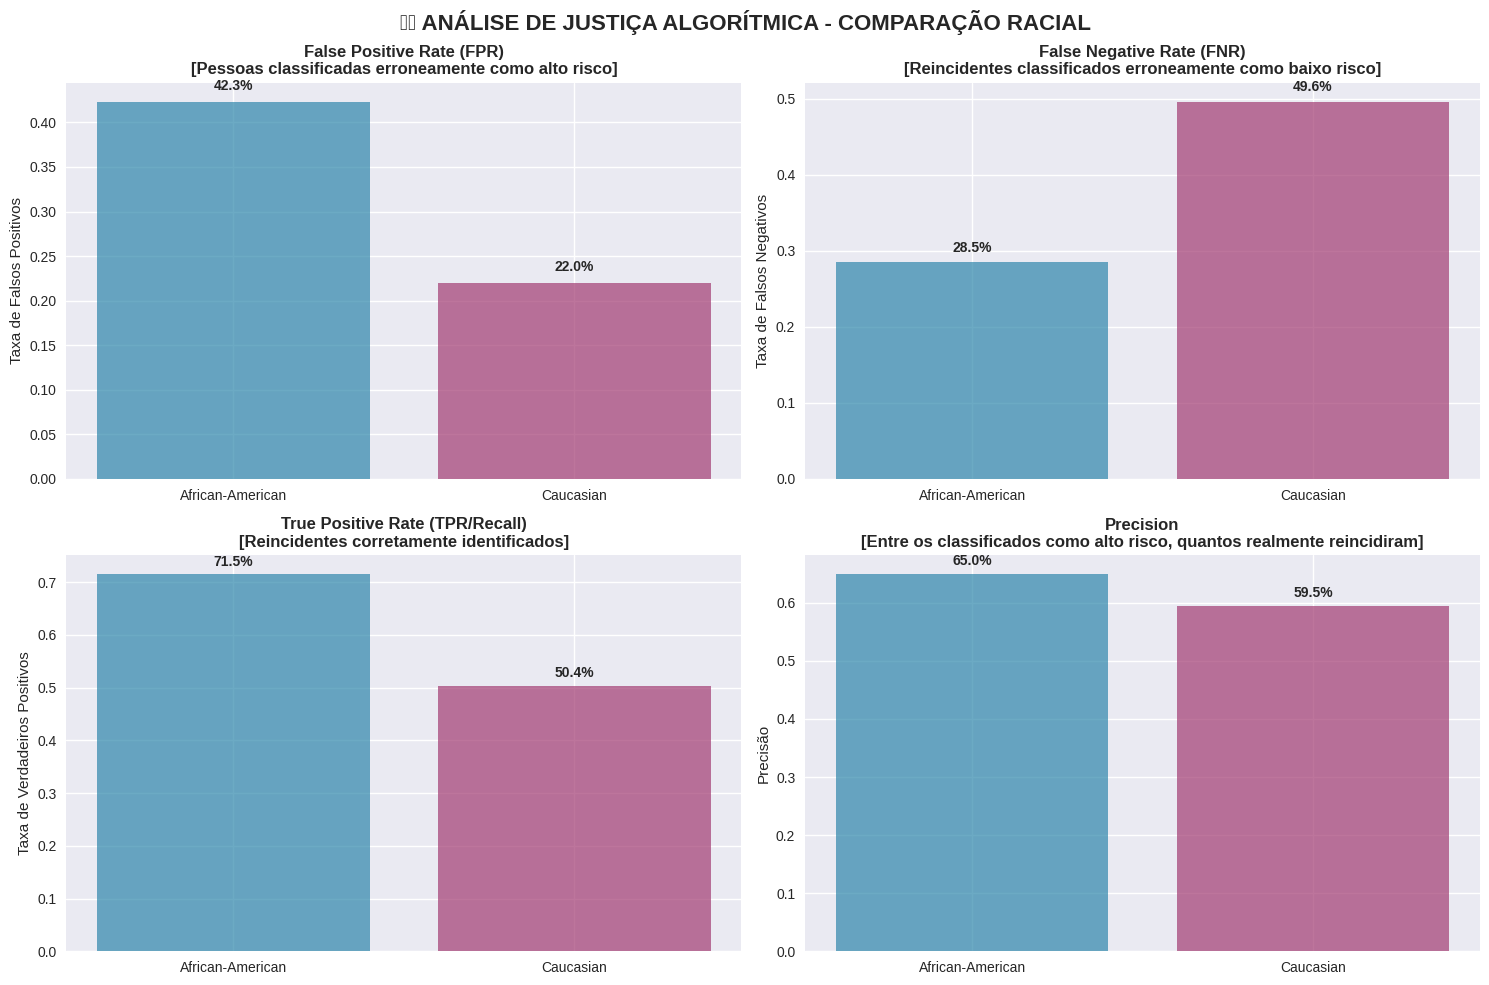

In [ ]:
# 1.9 VISUALIZAÇÃO DAS MÉTRICAS DE FAIRNESS
# =============================================================================
# Representação gráfica das disparidades nas taxas de erro entre grupos
# raciais, destacando possíveis vieses do algoritmo
# =============================================================================

print("📈 VISUALIZAÇÃO DAS DISPARIDADES NAS TAXAS DE ERRO")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('⚖️ ANÁLISE DE JUSTIÇA ALGORÍTMICA - COMPARAÇÃO RACIAL',
             fontsize=16, fontweight='bold', y=0.98)

# False Positive Rate
bars1 = axes[0,0].bar(bias_df['race'], bias_df['fpr'], color=['#2E86AB', '#A23B72'], alpha=0.7)
axes[0,0].set_title('False Positive Rate (FPR)\n[Pessoas classificadas erroneamente como alto risco]',
                    fontweight='bold')
axes[0,0].set_ylabel('Taxa de Falsos Positivos')
axes[0,0].tick_params(axis='x', rotation=0)
for bar, valor in zip(bars1, bias_df['fpr']):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                  f'{valor:.1%}', ha='center', va='bottom', fontweight='bold')

# False Negative Rate
bars2 = axes[0,1].bar(bias_df['race'], bias_df['fnr'], color=['#2E86AB', '#A23B72'], alpha=0.7)
axes[0,1].set_title('False Negative Rate (FNR)\n[Reincidentes classificados erroneamente como baixo risco]',
                    fontweight='bold')
axes[0,1].set_ylabel('Taxa de Falsos Negativos')
axes[0,1].tick_params(axis='x', rotation=0)
for bar, valor in zip(bars2, bias_df['fnr']):
    axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                  f'{valor:.1%}', ha='center', va='bottom', fontweight='bold')

# True Positive Rate (Recall)
bars3 = axes[1,0].bar(bias_df['race'], bias_df['tpr'], color=['#2E86AB', '#A23B72'], alpha=0.7)
axes[1,0].set_title('True Positive Rate (TPR/Recall)\n[Reincidentes corretamente identificados]',
                    fontweight='bold')
axes[1,0].set_ylabel('Taxa de Verdadeiros Positivos')
axes[1,0].tick_params(axis='x', rotation=0)
for bar, valor in zip(bars3, bias_df['tpr']):
    axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                  f'{valor:.1%}', ha='center', va='bottom', fontweight='bold')

# Precision
bars4 = axes[1,1].bar(bias_df['race'], bias_df['precision'], color=['#2E86AB', '#A23B72'], alpha=0.7)
axes[1,1].set_title('Precision\n[Entre os classificados como alto risco, quantos realmente reincidiram]',
                    fontweight='bold')
axes[1,1].set_ylabel('Precisão')
axes[1,1].tick_params(axis='x', rotation=0)
for bar, valor in zip(bars4, bias_df['precision']):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                  f'{valor:.1%}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# 1.10 RESUMO CONCLUSIVO DA ETAPA 1
# =============================================================================
# Síntese dos principais achados e estabelecimento das bases para as
# próximas etapas de modelagem e análise de fairness
# =============================================================================

print("=" * 80)
print("🎯 RESUMO CONCLUSIVO - ETAPA 1: ANÁLISE EXPLORATÓRIA")
print("=" * 80)

# Principais estatísticas
aa_subset = df_principal[df_principal['race'] == 'African-American']
caucasian_subset = df_principal[df_principal['race'] == 'Caucasian']

fpr_aa = bias_df[bias_df['race'] == 'African-American']['fpr'].values[0]
fpr_caucasian = bias_df[bias_df['race'] == 'Caucasian']['fpr'].values[0]
fpr_ratio = fpr_aa / fpr_caucasian

print(f"\n📊 BASE DE ANÁLISE:")
print(f"   • Dataset final: {len(df_principal)} casos (African-American vs Caucasian)")
print(f"   • African-American: {len(aa_subset)} casos ({len(aa_subset)/len(df_principal)*100:.1f}%)")
print(f"   • Caucasian: {len(caucasian_subset)} casos ({len(caucasian_subset)/len(df_principal)*100:.1f}%)")

print(f"\n⚖️ PRINCIPAIS ACHADOS SOBRE VIÉS:")

print(f"\n   📈 DISPARIDADES NA CLASSIFICAÇÃO:")
print(f"   • High Score: African-Americans = {cross_tab.loc['African-American', 'High']:.1f}% vs Caucasians = {cross_tab.loc['Caucasian', 'High']:.1f}%")
print(f"   • Low Score: African-Americans = {cross_tab.loc['African-American', 'Low']:.1f}% vs Caucasians = {cross_tab.loc['Caucasian', 'Low']:.1f}%")

print(f"\n   🚨 DISPARIDADES NAS TAXAS DE ERRO:")
print(f"   • False Positive Rate: African-Americans = {fpr_aa:.1%} vs Caucasians = {fpr_caucasian:.1%}")
print(f"   • African-Americans têm {fpr_ratio:.1f}x mais chances de serem falsos positivos")

print(f"\n   🎯 ACURÁCIA PREDITIVA:")
print(f"   • Reincidência real - African-Americans: {aa_subset['two_year_recid'].mean():.1%}")
print(f"   • Reincidência real - Caucasians: {caucasian_subset['two_year_recid'].mean():.1%}")
print(f"   • Precisão (African-Americans): {bias_df[bias_df['race'] == 'African-American']['precision'].values[0]:.1%}")
print(f"   • Precisão (Caucasians): {bias_df[bias_df['race'] == 'Caucasian']['precision'].values[0]:.1%}")

print(f"\n🔮 PRÓXIMOS PASSOS:")
print(f"   • Etapa 2: Modelagem preditiva para comparar com COMPAS")
print(f"   • Etapa 3: Análise explicativa da 'lógica' do COMPAS")
print(f"   • Etapa 4: Análise abrangente de justiça algorítmica")

print(f"\n✅ ETAPA 1 CONCLUÍDA COM SUCESSO!")
print("   • Base analítica estabelecida")
print("   • Padrões de viés identificados")
print("   • Fundamentos para modelagem preparados")

🎯 RESUMO CONCLUSIVO - ETAPA 1: ANÁLISE EXPLORATÓRIA

📊 BASE DE ANÁLISE:
   • Dataset final: 5278 casos (African-American vs Caucasian)
   • African-American: 3175 casos (60.2%)
   • Caucasian: 2103 casos (39.8%)

⚖️ PRINCIPAIS ACHADOS SOBRE VIÉS:

   📈 DISPARIDADES NA CLASSIFICAÇÃO:
   • High Score: African-Americans = 26.6% vs Caucasians = 10.6%
   • Low Score: African-Americans = 42.4% vs Caucasians = 66.9%

   🚨 DISPARIDADES NAS TAXAS DE ERRO:
   • False Positive Rate: African-Americans = 42.3% vs Caucasians = 22.0%
   • African-Americans têm 1.9x mais chances de serem falsos positivos

   🎯 ACURÁCIA PREDITIVA:
   • Reincidência real - African-Americans: 52.3%
   • Reincidência real - Caucasians: 39.1%
   • Precisão (African-Americans): 65.0%
   • Precisão (Caucasians): 59.5%

🔮 PRÓXIMOS PASSOS:
   • Etapa 2: Modelagem preditiva para comparar com COMPAS
   • Etapa 3: Análise explicativa da 'lógica' do COMPAS
   • Etapa 4: Análise abrangente de justiça algorítmica

✅ ETAPA 1 CONCLUÍD

## Não Executar

In [ ]:
# 🔧 CONFIGURAÇÃO COMPLETA DO GOOGLE DRIVE PARA O TCC
print("🎯 CONFIGURANDO ESTRUTURA DO TCC NO GOOGLE DRIVE...")

from google.colab import drive
import os
import pandas as pd
import pickle
import shutil
from datetime import datetime

# Montar Google Drive
print("📁 Montando Google Drive...")
drive.mount('/content/drive')

# Definir caminho base
base_path = '/content/drive/MyDrive/TCC_COMPAS'
print(f"📍 Caminho base: {base_path}")

# Criar estrutura de pastas
pastas = [
    'data',           # 📊 Dados processados
    'notebooks',      # 📓 Jupyter notebooks
    'utils',          # 🛠️ Funções auxiliares
    'results',        # 📈 Resultados e gráficos
    'models',         # 🤖 Modelos treinados
    'backups',        # 💾 Backups
    'docs'            # 📋 Documentação
]

print("📂 Criando estrutura de pastas...")
for pasta in pastas:
    os.makedirs(f'{base_path}/{pasta}', exist_ok=True)
    print(f"   ✅ {pasta}/")

print("🏗️ ESTRUTURA CRIADA COM SUCESSO!")

🎯 CONFIGURANDO ESTRUTURA DO TCC NO GOOGLE DRIVE...
📁 Montando Google Drive...
Mounted at /content/drive
📍 Caminho base: /content/drive/MyDrive/TCC_COMPAS
📂 Criando estrutura de pastas...
   ✅ data/
   ✅ notebooks/
   ✅ utils/
   ✅ results/
   ✅ models/
   ✅ backups/
   ✅ docs/
🏗️ ESTRUTURA CRIADA COM SUCESSO!


In [ ]:
# 🔍 VERIFICANDO ESTRUTURA CRIADA
print("🔍 VERIFICAÇÃO DA ESTRUTURA DE PASTAS:")

def listar_estrutura(caminho, nivel=0):
    """Lista recursivamente a estrutura de pastas"""
    if os.path.exists(caminho):
        for item in os.listdir(caminho):
            item_path = os.path.join(caminho, item)
            espacos = "  " * nivel
            if os.path.isdir(item_path):
                print(f"{espacos}📁 {item}/")
                listar_estrutura(item_path, nivel + 1)
            else:
                print(f"{espacos}📄 {item}")

listar_estrutura(base_path)

print(f"\n📍 Localização completa: {base_path}")

🔍 VERIFICAÇÃO DA ESTRUTURA DE PASTAS:
📁 data/
📁 notebooks/
📁 utils/
📁 results/
📁 models/
📁 backups/
📁 docs/

📍 Localização completa: /content/drive/MyDrive/TCC_COMPAS


In [ ]:
# 💾 EXPORTAÇÃO DOS DADOS PROCESSADOS
print("💾 SALVANDO DADOS DA ETAPA 1 NO DRIVE...")

# Verificar se temos os dataframes necessários
print("📋 Verificando dataframes disponíveis...")
dataframes_disponiveis = []
for var in ['df_principal', 'bias_df', 'cross_tab', 'df_filtered']:
    if var in globals():
        dataframes_disponiveis.append(var)
        print(f"   ✅ {var}: {globals()[var].shape}")

if not dataframes_disponiveis:
    print("❌ Nenhum dataframe encontrado. Execute a Etapa 1 primeiro!")
else:
    # Preparar dados para exportação
    dados_exportados = {
        'df_principal': df_principal,
        'bias_df': bias_df,
        'metadata': {
            'dataset_original': 'compas-scores-two-years.csv',
            'original_shape': df.shape if 'df' in globals() else 'N/A',
            'filtered_shape': df_filtered.shape if 'df_filtered' in globals() else 'N/A',
            'final_shape': df_principal.shape,
            'races_incluidas': list(df_principal['race'].unique()),
            'filtros_aplicados': 'ProPublica (30 dias, F/M charges, recid != -1)',
            'processing_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
            'total_casos': len(df_principal),
            'proporcao_racial': df_principal['race'].value_counts(normalize=True).to_dict(),
            'versao_exportacao': '1.0'
        }
    }

    # Adicionar cross_tab se disponível
    if 'cross_tab' in globals():
        dados_exportados['cross_tab'] = cross_tab

    # Salvar em pickle (formato eficiente)
    with open(f'{base_path}/data/compas_processed.pkl', 'wb') as f:
        pickle.dump(dados_exportados, f)

    # Salvar em CSV para inspeção
    df_principal.to_csv(f'{base_path}/data/compas_processed.csv', index=False)
    bias_df.to_csv(f'{base_path}/data/bias_metrics.csv', index=False)

    print("✅ DADOS EXPORTADOS COM SUCESSO!")
    print(f"📍 Local: {base_path}/data/")
    print(f"📊 Arquivos salvos:")
    print(f"   • compas_processed.pkl - Dataset completo")
    print(f"   • compas_processed.csv - Dataset em CSV")
    print(f"   • bias_metrics.csv - Métricas de viés")

💾 SALVANDO DADOS DA ETAPA 1 NO DRIVE...
📋 Verificando dataframes disponíveis...
   ✅ df_principal: (5278, 54)
   ✅ bias_df: (2, 11)
   ✅ cross_tab: (2, 3)
   ✅ df_filtered: (6172, 53)
✅ DADOS EXPORTADOS COM SUCESSO!
📍 Local: /content/drive/MyDrive/TCC_COMPAS/data/
📊 Arquivos salvos:
   • compas_processed.pkl - Dataset completo
   • compas_processed.csv - Dataset em CSV
   • bias_metrics.csv - Métricas de viés


In [ ]:
# 🛠️ CRIAR ARQUIVO UTILS PARA CARREGAMENTO
print("🛠️ CRIANDO FUNÇÕES DE CARREGAMENTO...")

utils_code = '''
import pandas as pd
import pickle
import os

def load_compas_data():
    """
    Carrega dados processados do COMPAS do Google Drive

    Returns:
        dict: Dicionário com 'df_principal', 'bias_df', 'metadata'
    """
    base_path = '/content/drive/MyDrive/TCC_COMPAS'
    file_path = f'{base_path}/data/compas_processed.pkl'

    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Arquivo não encontrado: {file_path}")

    with open(file_path, 'rb') as f:
        data = pickle.load(f)

    print("✅ DADOS CARREGADOS COM SUCESSO!")
    print(f"📊 Dataset: {data['df_principal'].shape}")
    print(f"📈 Métricas de viés: {data['bias_df'].shape}")
    print(f"🕐 Processado em: {data['metadata']['processing_date']}")
    print(f"👥 Casos: {data['metadata']['total_casos']}")

    return data

def get_dataframes():
    """
    Retorna dataframes principais de forma conveniente

    Returns:
        tuple: (df_principal, bias_df, metadata)
    """
    data = load_compas_data()
    return data['df_principal'], data['bias_df'], data['metadata']

def setup_environment():
    """
    Configura ambiente completo para análise
    """
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    import warnings
    warnings.filterwarnings('ignore')

    # Configurações de visualização
    plt.style.use('seaborn-v0_8')
    sns.set_palette("husl")

    print("🎉 AMBIENTE CONFIGURADO!")
    print("   • Pandas, NumPy, Matplotlib, Seaborn")
    print("   • Visualizações configuradas")
    print("   • Warnings desativados")

    return load_compas_data()
'''

# Salvar arquivo utils
with open(f'{base_path}/utils/data_loader.py', 'w') as f:
    f.write(utils_code)

print("✅ ARQUIVO UTILS SALVO!")
print(f"📍 Local: {base_path}/utils/data_loader.py")

🛠️ CRIANDO FUNÇÕES DE CARREGAMENTO...
✅ ARQUIVO UTILS SALVO!
📍 Local: /content/drive/MyDrive/TCC_COMPAS/utils/data_loader.py


In [ ]:
# 📓 CRIANDO TEMPLATE PARA NOTEBOOK 2
print("📓 PREPARANDO TEMPLATE PARA PRÓXIMO NOTEBOOK...")

template_code = '''# -*- coding: utf-8 -*-
# NOTEBOOK 2: MODELAGEM PREDITIVA - COMPAS
# =============================================================================
# TCC: Análise de Viés no Algoritmo COMPAS
# Autor: [Seu Nome]
# Data: [Data]
# =============================================================================

print("🚀 NOTEBOOK 2: MODELAGEM PREDITIVA")
print("=" * 60)

# 1. CONFIGURAÇÃO INICIAL
# =============================================================================
print("🔧 CONFIGURANDO AMBIENTE...")

from google.colab import drive
import sys

# Montar Google Drive
drive.mount('/content/drive')

# Configurar caminhos
base_path = '/content/drive/MyDrive/TCC_COMPAS'
sys.path.append(f'{base_path}/utils')

# Importar função de carregamento
from data_loader import setup_environment

# Carregar dados e configurar ambiente
data = setup_environment()
df_principal = data['df_principal']
bias_df = data['bias_df']
metadata = data['metadata']

print("✅ AMBIENTE PRONTO PARA MODELAGEM!")
print(f"📊 Dataset: {df_principal.shape}")
print(f"🎯 Variáveis disponíveis: {list(df_principal.columns)}")

# 2. PRÉ-PROCESSAMENTO PARA MODELAGEM
# =============================================================================
print("\\n🔧 PREPARANDO DADOS PARA MODELAGEM...")

# Suas transformações aqui...

# 3. MODELAGEM PREDITIVA
# =============================================================================
print("\\n🤖 INICIANDO MODELAGEM PREDITIVA...")

# Seus modelos aqui...

print("✅ NOTEBOOK 2 CONFIGURADO!")
print("🎯 Pronto para implementar a modelagem preditiva!")
'''

# Salvar template
with open(f'{base_path}/notebooks/02_Modelagem_Preditiva.ipynb', 'w') as f:
    f.write(template_code)

print("✅ TEMPLATE DO NOTEBOOK 2 CRIADO!")

📓 PREPARANDO TEMPLATE PARA PRÓXIMO NOTEBOOK...
✅ TEMPLATE DO NOTEBOOK 2 CRIADO!


In [ ]:
# ✅ VERIFICAÇÃO FINAL DA ESTRUTURA
print("✅ VERIFICAÇÃO FINAL DA ESTRUTURA DO TCC")

import glob

print("\\n📁 ESTRUTURA COMPLETA:")
for root, dirs, files in os.walk(base_path):
    level = root.replace(base_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}📁 {os.path.basename(root)}/")
    subindent = ' ' * 2 * (level + 1)
    for file in files:
        print(f"{subindent}📄 {file}")

print(f"\n🎯 PRÓXIMOS PASSOS:")
print("1. ✅ Estrutura criada no Google Drive")
print("2. ✅ Dados da Etapa 1 exportados")
print("3. ✅ Funções de carregamento criadas")
print("4. ✅ Template do Notebook 2 preparado")
print("5. 🚀 Pronto para iniciar Notebook 2!")

print(f"\\n📍 ACESSO AOS ARQUIVOS:")
print(f"   Google Drive → MyDrive → TCC_COMPAS")
print(f"   📊 Dados: /data/")
print(f"   📓 Notebooks: /notebooks/")
print(f"   🛠️ Utils: /utils/")

✅ VERIFICAÇÃO FINAL DA ESTRUTURA DO TCC
\n📁 ESTRUTURA COMPLETA:
📁 TCC_COMPAS/
  📁 data/
    📄 compas_processed.pkl
    📄 compas_processed.csv
    📄 bias_metrics.csv
  📁 notebooks/
    📄 02_Modelagem_Preditiva.ipynb
  📁 utils/
    📄 data_loader.py
  📁 results/
  📁 models/
  📁 backups/
  📁 docs/
\n🎯 PRÓXIMOS PASSOS:
1. ✅ Estrutura criada no Google Drive
2. ✅ Dados da Etapa 1 exportados
3. ✅ Funções de carregamento criadas
4. ✅ Template do Notebook 2 preparado
5. 🚀 Pronto para iniciar Notebook 2!
\n📍 ACESSO AOS ARQUIVOS:
   Google Drive → MyDrive → TCC_COMPAS
   📊 Dados: /data/
   📓 Notebooks: /notebooks/
   🛠️ Utils: /utils/
